# 생물물리 여름학교: Markov chain 101 실습

이 노트북은 PPT의 다섯 가지 task를 **시뮬레이션으로 직접 확인**하기 위한 Colab 실습 자료입니다.

- **Task 1**: Wright-Fisher DTMC에서 allele frequency trajectory 관찰
- **Task 2**: Birth-death CTMC의 분포 $P(X,t)$ 추정
- **Task 3**: Birth-death CTMC의 moment $\langle X(t)\rangle$, $\langle X^2(t)\rangle$ 확인
- **Task 4**: Chemical reaction network CTMC trajectory 시뮬레이션
- **Task 5**: 다른 chemical reaction network의 trajectory와 recurrence 확인

수업 시간에는 수식을 모두 증명하기보다, **코드를 실행하고 그림을 보면서 stochastic fluctuation이 어떻게 나타나는지** 보는 데 초점을 둡니다.


## 0. 준비

Colab에는 아래 패키지가 기본으로 들어 있습니다.


In [1]:
# 수치 계산과 그림 그리기에 필요한 기본 패키지입니다.
import numpy as np
import matplotlib.pyplot as plt

# Task 2에서 generator matrix의 exp(Qt)를 계산할 때만 SciPy를 사용합니다.
try:
    from scipy.linalg import expm
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# 재현 가능한 simulation을 위해 random seed를 고정합니다.
rng = np.random.default_rng(20260701)

# 그림 스타일을 미리 정해 두면 이후 plot들이 같은 형식으로 보입니다.
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print("NumPy version:", np.__version__)
print("SciPy available:", SCIPY_AVAILABLE)


NumPy version: 2.0.2
SciPy available: True


## Task 1. DTMC: allele frequency trajectory

한 세대에서 allele을 가진 개체 수를 $X_n$, 전체 개체 수를 $N$이라고 하겠습니다. 다음 세대의 allele 개체 수는

$$
P(X_{n+1}=k \mid X_n=i)
=
\binom{N}{k}
\left(\frac{i}{N}\right)^k
\left(1-\frac{i}{N}\right)^{N-k}.
$$

즉, 현재 frequency가 $p=X_n/N$이면 다음 세대 $X_{n+1}$은 `Binomial(N, p)`에서 뽑습니다.

아래 빈칸을 채워 $Y_n=X_n/N$ trajectory를 시뮬레이션해 봅시다.


**관찰 질문**

1. $N=10$과 $N=1000$ 중 어느 쪽 fluctuation이 더 크게 보이나요?
2. $Y_0=0.1$과 $Y_0=0.5$ 중 어느 쪽이 $0$ 또는 $1$에 더 빨리 도달하나요?
3. $X=0$, $X=N$ 상태가 한 번 나오면 왜 더 이상 변하지 않을까요?


In [2]:
def simulate_wright_fisher(N, y0, n_steps, rng):
    # X[n]은 n번째 generation에서 allele을 가진 개체 수입니다.
    X = np.empty(n_steps + 1, dtype=int)

    # initial frequency y0를 initial count X_0로 바꿉니다.
    X[0] = int(round(N * y0))

    for n in range(n_steps):
        # Markov property: 다음 세대는 현재 X[n]에만 의존합니다.
        p = X[n] / N

        # 다음 세대의 allele count는 Binomial(N, p)에서 뽑습니다.
        X[n + 1] = rng.binomial(N, p)

    # count trajectory를 frequency trajectory로 변환합니다.
    Y = X / N
    return X, Y


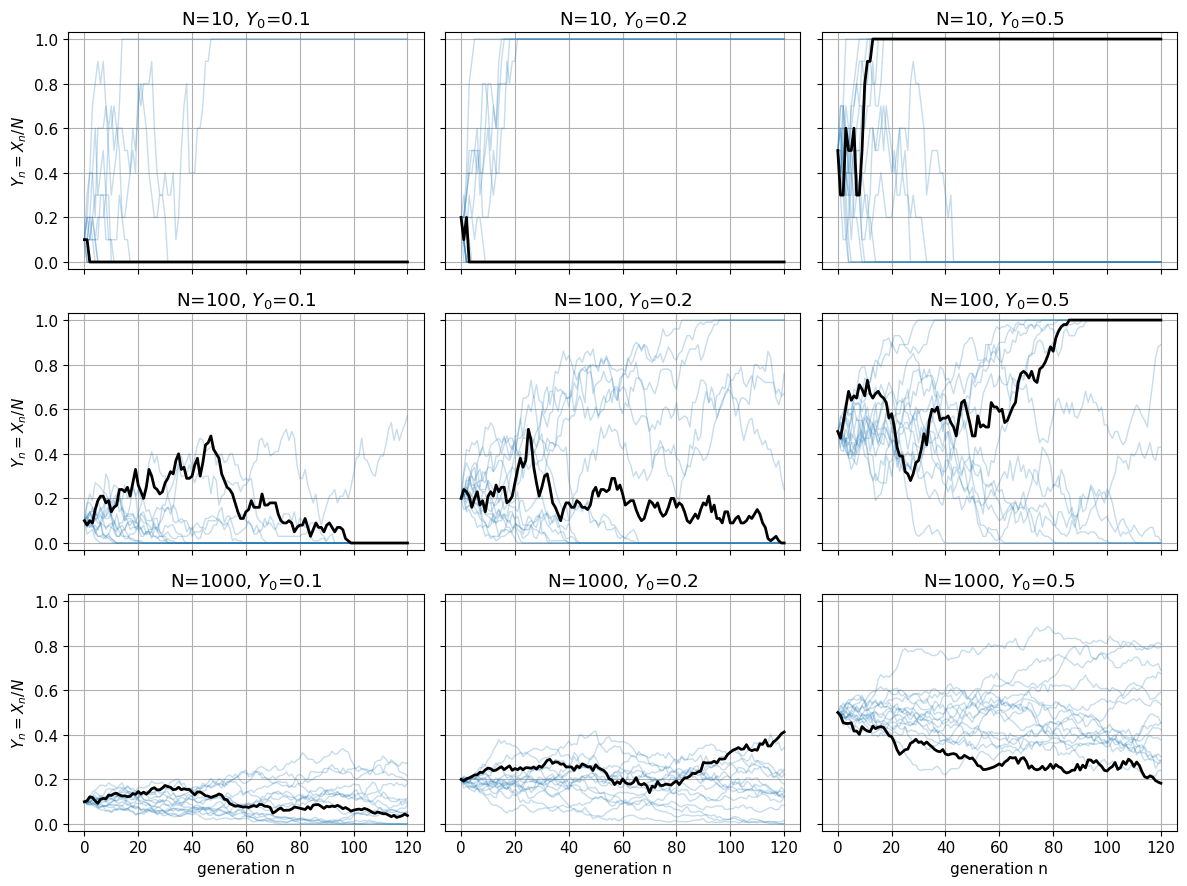

In [3]:
# 비교할 population size와 initial allele frequency입니다.
N_values = [10, 100, 1000]
y0_values = [0.1, 0.2, 0.5]

# 같은 조건에서 여러 trajectory를 그려 stochastic fluctuation을 봅니다.
n_steps = 120
n_reps = 15

fig, axes = plt.subplots(len(N_values), len(y0_values), figsize=(12, 9), sharex=True, sharey=True)

for i, N in enumerate(N_values):
    for j, y0 in enumerate(y0_values):
        ax = axes[i, j]

        # 조건마다 seed를 다르게 주어 그림이 반복 실행해도 안정적으로 재현되게 합니다.
        local_rng = np.random.default_rng(1000 + 17 * N + int(100 * y0))

        # 옅은 선들은 같은 조건에서 나온 여러 sample paths입니다.
        for rep in range(n_reps):
            _, Y = simulate_wright_fisher(N, y0, n_steps, local_rng)
            ax.plot(Y, color="tab:blue", alpha=0.25, linewidth=1)

        # 검은 선 하나를 강조해서 single trajectory의 움직임을 봅니다.
        _, Y_one = simulate_wright_fisher(N, y0, n_steps, local_rng)
        ax.plot(Y_one, color="black", linewidth=2)
        ax.set_title(f"N={N}, $Y_0$={y0}")
        ax.set_ylim(-0.03, 1.03)

        if i == len(N_values) - 1:
            ax.set_xlabel("generation n")
        if j == 0:
            ax.set_ylabel(r"$Y_n=X_n/N$")

plt.tight_layout()
plt.show()


**해답 메모**

$N$이 작을수록 binomial sampling noise가 상대적으로 커서 allele frequency가 크게 흔들립니다. $Y_0$가 경계에 가까우면 absorbing state인 $0$ 또는 $1$에 더 빨리 닿는 경향이 있습니다.


## Task 2-3. CTMC: birth-death model

이번에는 continuous time에서 population $X(t)$가 birth/death를 겪는 모델을 봅니다.

$$
q_{x,x+1}=bx,\qquad
q_{x,x-1}=dx \quad (x\ge 1).
$$

현재 $X=x$이면 전체 jump rate는 $(b+d)x$입니다. 기다리는 시간은 exponential distribution에서 뽑고, jump가 일어날 때 birth인지 death인지를 확률적으로 정합니다.


In [4]:
def simulate_birth_death(x0, b, d, t_grid, rng):
    # values[j]는 관찰 시간 t_grid[j]에서의 X(t)를 저장합니다.
    values = np.empty(len(t_grid), dtype=int)

    # t는 현재 CTMC 시간, x는 현재 state입니다.
    t = 0.0
    x = int(x0)
    j = 0

    while j < len(t_grid):
        # x=0에서는 birth/death rate가 모두 0이므로 absorbing state입니다.
        if x == 0:
            values[j:] = 0
            break

        # 현재 state x에서 전체 jump rate를 계산합니다.
        total_rate = (b + d) * x

        # 다음 jump까지의 waiting time은 Exponential(total_rate)입니다.
        tau = rng.exponential(1 / total_rate)

        # jump가 일어나기 전까지의 관찰값은 모두 현재 state x입니다.
        while j < len(t_grid) and t_grid[j] < t + tau:
            values[j] = x
            j += 1

        # 실제 CTMC 시간을 다음 jump 시점으로 옮깁니다.
        t = t + tau

        # jump direction을 정합니다: birth with probability b/(b+d).
        birth_probability = b / (b + d)
        if rng.random() < birth_probability:
            x += 1
        else:
            x -= 1

    return values


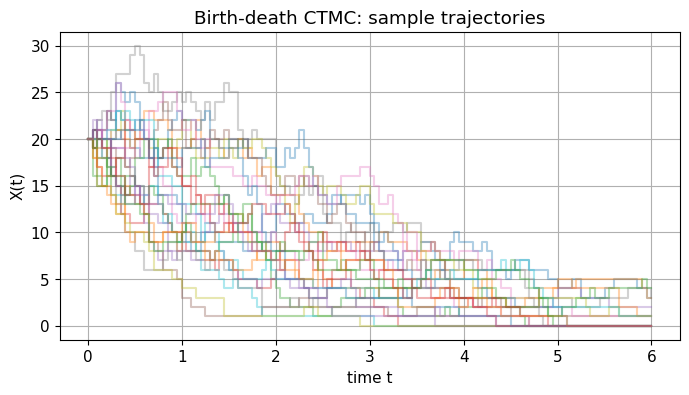

In [5]:
# b < d로 두면 평균적으로 population이 감소하는 subcritical birth-death process가 됩니다.
b = 0.8
d = 1.2
x0 = 20

# CTMC는 continuous time process이지만, 그림과 평균 계산을 위해 관찰 시간 grid를 정합니다.
t_grid = np.linspace(0, 6, 121)
n_paths = 2000

# 많은 trajectory를 한 번에 저장합니다. 각 row가 하나의 sample path입니다.
bd_rng = np.random.default_rng(123)
paths = np.array([
    simulate_birth_death(x0, b, d, t_grid, bd_rng)
    for _ in range(n_paths)
])

# 먼저 일부 trajectory만 그려서 CTMC의 jump 형태를 확인합니다.
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(25):
    ax.step(t_grid, paths[k], where="post", alpha=0.35)

ax.set_xlabel("time t")
ax.set_ylabel("X(t)")
ax.set_title("Birth-death CTMC: sample trajectories")
plt.show()


### Task 2. 분포 $P(X,t)$

같은 시간 $t$에서 많은 trajectory의 $X(t)$ 값을 모으면, 그 histogram이 $P(X,t)$의 simulation estimate입니다.


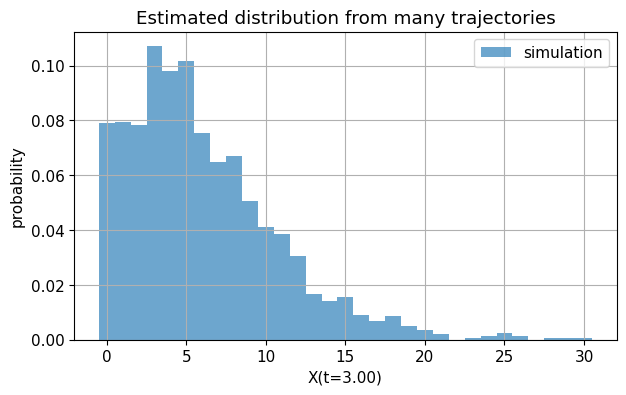

Estimated P(X=0, t): 0.079
Most frequent X: 3


In [6]:
# t_obs 근처에서 모든 trajectory의 X(t)를 모으면 분포 P(X,t)를 추정할 수 있습니다.
t_obs = 3.0
idx = np.argmin(np.abs(t_grid - t_obs))
samples = paths[:, idx]

# integer-valued state이므로 bin의 중심이 0, 1, 2, ...가 되도록 맞춥니다.
plt.figure(figsize=(7, 4))
bins = np.arange(samples.max() + 2) - 0.5
plt.hist(samples, bins=bins, density=True, alpha=0.65, label="simulation")
plt.xlabel(f"X(t={t_grid[idx]:.2f})")
plt.ylabel("probability")
plt.title("Estimated distribution from many trajectories")
plt.legend()
plt.show()

# extinction probability와 mode를 간단히 출력합니다.
print("Estimated P(X=0, t):", np.mean(samples == 0))
print("Most frequent X:", np.bincount(samples).argmax())


아래는 finite-state generator matrix를 이용한 참고용 계산입니다. 수업 시간이 부족하면 실행만 해보고 넘어가도 됩니다.


In [7]:
def bd_distribution_matrix(x0, b, d, t, xmax=80):
    # Q[i, j]는 state i에서 state j로 가는 transition rate입니다.
    Q = np.zeros((xmax + 1, xmax + 1))

    for x in range(xmax + 1):
        if x + 1 <= xmax:
            Q[x, x + 1] = b * x
        if x >= 1:
            Q[x, x - 1] = d * x

        # 각 row의 합이 0이 되도록 diagonal entry를 채웁니다.
        Q[x, x] = -Q[x].sum()

    # 처음에는 x0에 probability 1이 있습니다.
    p0 = np.zeros(xmax + 1)
    p0[x0] = 1.0

    # CTMC의 분포는 p(t)=p(0) exp(Qt)입니다.
    return p0 @ expm(Q * t)


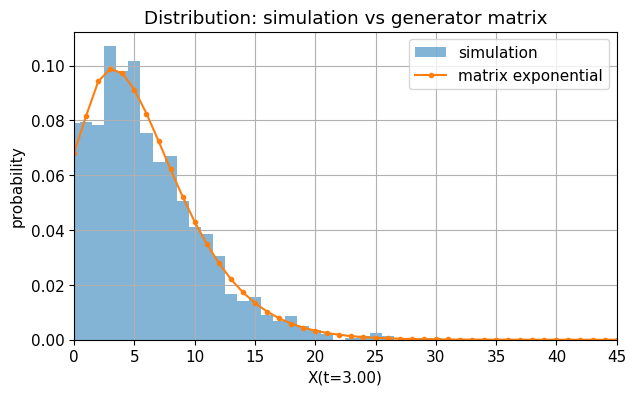

In [8]:
if SCIPY_AVAILABLE:
    # finite state로 잘라낸 generator Q를 이용해 p(t)=p(0) exp(Qt)를 계산합니다.
    p_exact = bd_distribution_matrix(x0, b, d, t_grid[idx], xmax=80)

    plt.figure(figsize=(7, 4))
    plt.hist(samples, bins=bins, density=True, alpha=0.55, label="simulation")
    plt.plot(np.arange(len(p_exact)), p_exact, "o-", markersize=3, label="matrix exponential")
    plt.xlim(0, max(45, np.percentile(samples, 99) + 3))
    plt.xlabel(f"X(t={t_grid[idx]:.2f})")
    plt.ylabel("probability")
    plt.title("Distribution: simulation vs generator matrix")
    plt.legend()
    plt.show()
else:
    print("SciPy is not available, so the matrix exponential comparison is skipped.")


### Task 3. Moment $\langle X(t)\rangle$, $\langle X^2(t)\rangle$

Simulation에서는 여러 trajectory에 대해 평균을 내면 됩니다.

$$
\langle X(t)\rangle \approx \frac{1}{M}\sum_{m=1}^M X_m(t),\qquad
\langle X^2(t)\rangle \approx \frac{1}{M}\sum_{m=1}^M X_m(t)^2.
$$


In [9]:
# axis=0은 trajectory index를 평균내고, 각 관찰 시간별 평균을 남깁니다.
mean_emp = paths.mean(axis=0)

# X(t)^2를 먼저 만든 뒤 trajectory 평균을 냅니다.
second_emp = (paths ** 2).mean(axis=0)

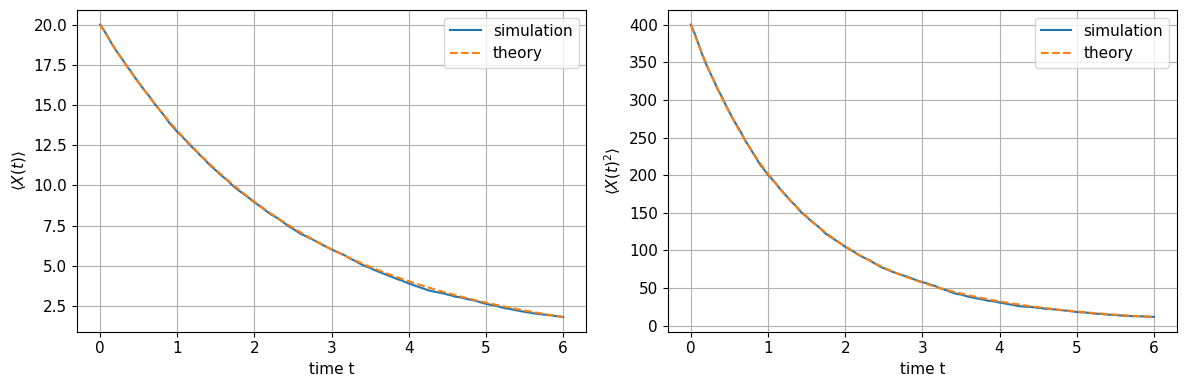

In [10]:
def theoretical_moments_birth_death(x0, b, d, t):
    # a는 net growth rate입니다. a<0이면 평균 population이 감소합니다.
    a = b - d
    mean = x0 * np.exp(a * t)

    # Var[X(t)] 공식입니다. b=d인 critical case는 극한식을 따로 씁니다.
    if abs(a) < 1e-12:
        var = 2 * b * x0 * t
    else:
        var = x0 * (b + d) / a * np.exp(a * t) * (np.exp(a * t) - 1)

    second = var + mean ** 2
    return mean, second


mean_th, second_th = theoretical_moments_birth_death(x0, b, d, t_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 첫 번째 moment: trajectory 평균과 이론값을 비교합니다.
axes[0].plot(t_grid, mean_emp, label="simulation")
axes[0].plot(t_grid, mean_th, "--", label="theory")
axes[0].set_xlabel("time t")
axes[0].set_ylabel(r"$\langle X(t)\rangle$")
axes[0].legend()

# 두 번째 moment: fluctuation의 크기까지 반영되므로 값이 더 크게 변합니다.
axes[1].plot(t_grid, second_emp, label="simulation")
axes[1].plot(t_grid, second_th, "--", label="theory")
axes[1].set_xlabel("time t")
axes[1].set_ylabel(r"$\langle X(t)^2\rangle$")
axes[1].legend()

plt.tight_layout()
plt.show()


**해답 메모**

여기서는 $b<d$로 두었기 때문에 평균 population은 감소합니다. 하지만 한 trajectory만 보면 계단형 jump와 fluctuation이 커서 deterministic curve처럼 매끈하지 않습니다. 많은 trajectory 평균을 낼수록 이론 moment와 가까워집니다.


## Gillespie algorithm helper

Task 4와 Task 5는 chemical reaction network입니다. 공통적으로 Gillespie algorithm을 쓰겠습니다.

1. 현재 상태에서 각 reaction propensity $a_i(x)$를 계산합니다.
2. 전체 rate $a_0=\sum_i a_i$로 exponential waiting time을 뽑습니다.
3. $a_i/a_0$ 확률로 어떤 reaction이 일어날지 뽑습니다.
4. stoichiometry만큼 state를 바꿉니다.


In [11]:
def gillespie(x0, rate_function, stoichiometry, t_max, rng, max_events=100_000):
    # x는 현재 molecule count vector입니다.
    x = np.array(x0, dtype=int)

    # stoichiometry[r]는 reaction r이 일어날 때 state가 얼마나 변하는지 나타냅니다.
    stoichiometry = np.array(stoichiometry, dtype=int)

    t = 0.0
    times = [t]
    states = [x.copy()]

    for _ in range(max_events):
        # Step 1. 현재 state에서 각 reaction propensity를 계산합니다.
        rates = np.asarray(rate_function(x), dtype=float)
        rates = np.maximum(rates, 0.0)
        total_rate = rates.sum()

        # 가능한 reaction이 없으면 trajectory가 멈춥니다.
        if total_rate <= 0:
            break

        # Step 2. 전체 rate로 다음 reaction까지의 waiting time을 뽑습니다.
        tau = rng.exponential(1 / total_rate)
        t_next = t + tau

        # t_max를 넘으면 마지막 state를 t_max까지 유지한 것으로 기록합니다.
        if t_next > t_max:
            times.append(t_max)
            states.append(x.copy())
            break

        # Step 3. reaction r을 probability rates[r]/total_rate로 선택합니다.
        reaction = rng.choice(len(rates), p=rates / total_rate)

        # Step 4. 선택된 reaction의 stoichiometry만큼 state를 갱신합니다.
        x = x + stoichiometry[reaction]

        if np.any(x < 0):
            raise RuntimeError("Negative molecule count occurred. Check propensities.")

        t = t_next
        times.append(t)
        states.append(x.copy())

    return np.array(times), np.vstack(states)


def plot_species(times, states, labels, title):
    # step plot은 jump process의 piecewise-constant trajectory를 보여주기에 적합합니다.
    plt.figure(figsize=(8, 4))
    for i, label in enumerate(labels):
        plt.step(times, states[:, i], where="post", label=label)
    plt.xlabel("time t")
    plt.ylabel("molecule count")
    plt.title(title)
    plt.legend()
    plt.show()


## Task 4. Chemical reaction network CTMC

$$
A+B \overset{1}{\underset{3}{\rightleftharpoons}} C,
\qquad
A \overset{1}{\underset{1}{\rightleftharpoons}} \emptyset
\overset{1}{\underset{1}{\rightleftharpoons}} B.
$$

State는 $(A,B,C)$입니다.

Reaction 목록:

1. $A+B\to C$
2. $C\to A+B$
3. $A\to \emptyset$
4. $\emptyset\to A$
5. $B\to \emptyset$
6. $\emptyset\to B$


**관찰 질문**

1. $A$, $B$, $C$가 deterministic curve처럼 움직이나요, 아니면 jump가 뚜렷한가요?
2. 초기값을 `[2, 2, 0]`으로 낮추면 fluctuation이 더 잘 보이나요?
3. `t_max`를 늘리면 molecule count가 한 방향으로 계속 커지나요, 아니면 일정 범위에서 흔들리나요?

In [12]:
# 각 row는 reaction 하나의 state change [dA, dB, dC]입니다.
stoich4 = np.array([
    [-1, -1, +1],  # A+B -> C
    [+1, +1, -1],  # C -> A+B
    [-1,  0,  0],  # A -> empty
    [+1,  0,  0],  # empty -> A
    [ 0, -1,  0],  # B -> empty
    [ 0, +1,  0],  # empty -> B
])


def rates_task4(x):
    # 현재 state vector를 각 species count로 나눕니다.
    A, B, C = x

    # mass-action law에 따라 각 reaction propensity를 계산합니다.
    return np.array([
        A * B,     # A+B -> C
        3.0 * C,   # C -> A+B
        A,         # A -> empty
        1.0,       # empty -> A
        B,         # B -> empty
        1.0,       # empty -> B
    ], dtype=float)


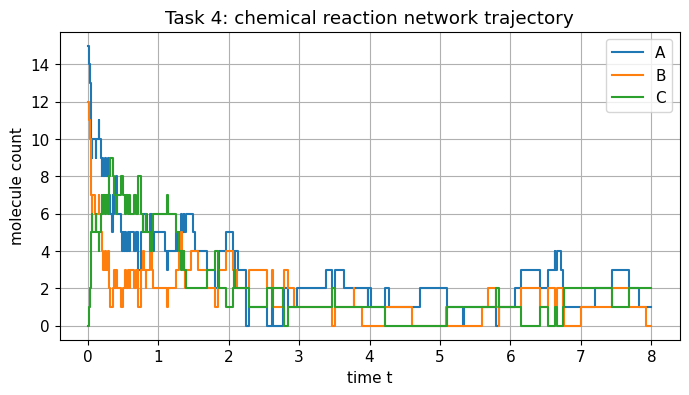

Number of reaction events: 137
Final state [A, B, C]: [1 0 2]


In [13]:
# 하나의 초기 조건에서 Task 4 network의 CTMC trajectory를 생성합니다.
times4, states4 = gillespie(
    x0=[15, 12, 0],
    rate_function=rates_task4,
    stoichiometry=stoich4,
    t_max=8,
    rng=np.random.default_rng(4),
)

plot_species(times4, states4, labels=["A", "B", "C"], title="Task 4: chemical reaction network trajectory")

print("Number of reaction events:", len(times4) - 1)
print("Final state [A, B, C]:", states4[-1])


**해답 메모**

이 network에는 $A$, $B$의 inflow/outflow가 있어서 molecule count가 계속 한 방향으로만 가지 않고 stochastic steady behavior처럼 흔들리는 모습을 볼 수 있습니다.


## Task 5. Chemical reaction network CTMC와 recurrence

$$
A+B \overset{1}{\underset{1}{\rightleftharpoons}} \emptyset,
\qquad
A+2B \xrightarrow{1} 2A+B.
$$

State는 $(A,B)$입니다.

Reaction 목록:

1. $A+B\to\emptyset$
2. $\emptyset\to A+B$
3. $A+2B\to 2A+B$

세 번째 reaction은 $A$ 하나와 $B$ 두 개가 만나야 하므로 stochastic mass-action propensity를

$$
A\binom{B}{2}=A\frac{B(B-1)}{2}
$$

로 둡니다.


In [ ]:
# 각 row는 reaction 하나의 state change [dA, dB]입니다.
stoich5 = np.array([
    [-1, -1],  # A+B -> empty
    [+1, +1],  # empty -> A+B
    [+1, -1],  # A+2B -> 2A+B
])


def rates_task5(x):
    A, B = x

    return np.array([
        A * B,                                      # A+B -> empty
        1.0,                                        # empty -> A+B
        A * B * (B - 1) / 2 if B >= 2 else 0.0,     # A+2B -> 2A+B
    ], dtype=float)


In [ ]:
# origin에서 출발해 Task 5 network의 한 trajectory를 봅니다.
times5, states5 = gillespie(
    x0=[0, 0],
    rate_function=rates_task5,
    stoichiometry=stoich5,
    t_max=20,
    rng=np.random.default_rng(5),
    max_events=50_000,
)

plot_species(times5, states5, labels=["A", "B"], title="Task 5: chemical reaction network trajectory")

# A-B가 감소하지 않는다는 점이 recurrence 판정의 핵심입니다.
delta = states5[:, 0] - states5[:, 1]
plt.figure(figsize=(8, 3))
plt.step(times5, delta, where="post", color="tab:red")
plt.xlabel("time t")
plt.ylabel("A - B")
plt.title("A-B never decreases")
plt.show()

print("Final state [A, B]:", states5[-1])
print("Final A-B:", delta[-1])


### Origin으로 돌아오는지 simulation으로 확인

$(0,0)$에서 시작한 뒤 다시 $(0,0)$으로 돌아오면 `returned`, 더 이상 origin으로 돌아올 수 없는 상태가 되면 `escaped`로 표시하겠습니다.

힌트: $A-B$를 보면 됩니다.


In [ ]:
def return_or_escape_trial(rng, t_max=100.0, max_events=100_000):
    # origin에서 출발합니다.
    x = np.array([0, 0], dtype=int)
    t = 0.0
    left_origin = False

    for _ in range(max_events):
        # 현재 state에서 Task 5의 propensity를 계산합니다.
        rates = rates_task5(x)
        total_rate = rates.sum()

        if total_rate <= 0:
            return "stuck", t, x.copy()

        # Gillespie step: waiting time과 reaction index를 뽑습니다.
        t += rng.exponential(1 / total_rate)
        if t > t_max:
            return "timeout", t, x.copy()

        reaction = rng.choice(len(rates), p=rates / total_rate)
        x = x + stoich5[reaction]

        # origin을 떠났는지 기록합니다.
        if not np.array_equal(x, [0, 0]):
            left_origin = True

        # origin을 떠난 뒤 다시 origin에 오면 returned입니다.
        if left_origin and np.array_equal(x, [0, 0]):
            return "returned", t, x.copy()

        # A-B가 한 번 양수가 되면 다시 origin으로 돌아갈 수 없습니다.
        if left_origin and x[0] > x[1]:
            return "escaped", t, x.copy()

    return "max_events", t, x.copy()


trial_rng = np.random.default_rng(55)
n_trials = 2000
outcomes = [return_or_escape_trial(trial_rng)[0] for _ in range(n_trials)]

labels, counts = np.unique(outcomes, return_counts=True)
for label, count in zip(labels, counts):
    print(f"{label:>10s}: {count:4d} / {n_trials} = {count / n_trials:.3f}")


**생각해 보기**

Reaction 1과 2는 $A-B$를 바꾸지 않습니다. Reaction 3은 $A-B$를 $2$만큼 증가시킵니다. 따라서 $A-B$는 감소하지 않습니다.

Origin $(0,0)$에서는 $A-B=0$입니다. 만약 한 번이라도 $A-B>0$이 되면, 다시 $A-B=0$인 origin으로 돌아갈 수 없습니다.


**해답 메모**

Simulation에서 `escaped`가 양의 비율로 나타납니다. 즉, origin에서 출발했을 때 다시 origin으로 돌아오지 못하는 path가 양의 확률로 존재합니다. 따라서 origin은 recurrent state가 아닙니다.


## 마무리

이번 실습에서 본 핵심은 세 가지입니다.

1. DTMC에서는 transition probability만으로 trajectory를 만들 수 있습니다.
2. CTMC에서는 waiting time과 jump direction을 함께 뽑아야 합니다.
3. Chemical reaction network도 state와 propensity, stoichiometry만 정하면 Gillespie algorithm으로 simulation할 수 있습니다.

시간이 남으면 다음을 바꿔 보세요.

- Task 1: $N$, $Y_0$, `n_steps`
- Task 2-3: $b>d$, $b=d$, $b<d$
- Task 4: 초기 molecule count
- Task 5: 시작 state와 `t_max`
